In [ ]:
# NOTEBOOK 03 — CLUSTERING NO SUPERVISADO (K-Means)

# En el Notebook 02 construí un modelo supervisado que predice
# si un envío llegará tarde usando el target (Reached.on.Time_Y.N).
# ahora voy a cambiar completamente de enfoque.

# en este notebook haré un K-Means:

# Preparación de datos: eliminar el target (el modelo no puede verlo),
# escalar las variables (K-Means es sensible a la escala)...

# Elección del num de clusters (k): método del Codo para encontrar el K óptimo,
# índice de Silhouette para validar la calidad de los clusters.

# Entrenamiento del modeloN

# Análisis: características decada cluster, tasa de retraso por cluster, visualización
# con PCA...


In [ ]:
# en el aprendizaje NO SUPERVISADOO el modelo NO conoce si los envíos llegaron
# tarde o no, solo ve las características del envío (peso, descuento, coste...)
# y encuentra por sí solo grupos de envíos que se parecen entre sí

# después veré qué tasa de retraso tiene cada grupo

# uso K-Means porque agrupa los datos en K clusters intentando que cada envío
# quede asignado al grupo cuyo centro (centroide) le queda más cerca.
# es iterativo: empieza con centroides aleatorios y los va ajustando
# hasta que los grupos se estabilizan

# mi objetivo de negocio es descubrir si existen perfiles naturales de envío
# en el dataset
# si encuentro un cluster con alta tasa de retraso y características
# comunes (peso alto, descuento elevado, coste alto...), la empresa
# puede identificar esos envíos en el momento del empaquetado y
# tomar medidas preventivas antes incluso de que salgan del almacén

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocesamiento
from sklearn.preprocessing import StandardScaler # escalar variables (obligatorio en K-Means)
from sklearn.decomposition import PCA # reducción de dimensiones para visualizar clusters en 2D

# modelo
from sklearn.cluster import KMeans

# métricas de evaluación del clustering
from sklearn.metrics import silhouette_score # mide qué tan bien definidos están los clusters
from sklearn.metrics import silhouette_samples

import warnings
warnings.filterwarnings('ignore')


In [16]:
# preparación de datos para clustering

# para clustering parto del df original y aplico solo el preprocesamiento
# necesario para clustering, que es distinto

# Aquí NO uso dummies, K-Means mide distancias entre puntos
# si añado 8 columnas binarias de almacén y modo de envío, el modelo puede
# agrupar los envíos por bloque de almacén o por modo de transporte en
# lugar de por perfil de riesgo, que es lo que me interesa

# me quedo solo con las 7 variables numéricasque capturan el comportamiento
# real del envío y del cliente

# Aquí tmbn preparo el target ANTES de entrenar
# guardo el target aparte para analizarlo DESPUÉS de hacer los clusters
# y descubrir si el modelo ha separado envíos con distinto nivel de riesgo

df = pd.read_csv('../data/shipping_data.csv')
df = df.drop(columns=['ID']) # elimino ID
print(f'{df.shape[0]} filas, {df.shape[1]} columnas')
df.head(11)

10999 filas, 11 columnas


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1
5,F,Flight,3,1,162,3,medium,F,12,1417,1
6,D,Flight,3,4,250,3,low,F,3,2371,1
7,F,Flight,4,1,233,2,low,F,48,2804,1
8,A,Flight,3,4,150,3,low,F,11,1861,1
9,B,Flight,3,2,164,3,medium,F,29,1187,1


In [17]:
# ahora codifico 'Product_importance'
# es la única variable que sí codifico, igual que en el notebook 02

# tiene un orden lógico (low < medium < high), así que la mapeo a números
# preservando esa jerarquía: low=1, medium=2, high=3
# a diferencia del One-Hot Encoding, este mapeo ordinal sí tiene sentido para
# K-Means porque mantiene las distancias proporcionales entre categorías

mapa_imp = {'low': 1, 'medium': 2, 'high': 3}
df['Product_importance'] = df['Product_importance'].map(mapa_imp)

print(df['Product_importance'].value_counts().sort_index())

Product_importance
1    5297
2    4754
3     948
Name: count, dtype: int64


In [18]:
# separo el target ANTES del clustering

# esto es lo más importante conceptualmente
# Reached.on.Time_Y.N NO puede entrar en el modelo
# si el modelo lo viera, estaría haciendo aprendizaje supervisado, no clustering
# lo guardo aparte y lo recupero al final para evaluar qué tasa de retraso tiene cada cluster

target = df['Reached.on.Time_Y.N']

print(f'Target guardado: {len(target)} valores')
print(f'Distribución: {(target==1).sum()} retrasos ({target.mean():.1%}), '
      f'{(target==0).sum()} puntuales ({1-target.mean():.1%})')

Target guardado: 10999 valores
Distribución: 6563 retrasos (59.7%), 4436 puntuales (40.3%)


In [19]:
# selaciiono las variables para clustering

# cojo las 7 variables numéricas que mejor describen el perfil de cada envío y
# del cliente
# expluyo las categóricas sin codificar

cols_cluster = [
    'Weight_in_gms', # peso físico del paquete en gramos
    'Discount_offered', # descuento aplicado al producto (%)
    'Cost_of_the_Product', # precio del producto en USD
    'Customer_care_calls', # número de llamadas al servicio de atención
    'Customer_rating', # valoración del cliente (1=peor, 5=mejor)
    'Prior_purchases', # número de compras anteriores del cliente
    'Product_importance'] # importancia del producto (1=low, 2=medium, 3=high)

X_cluster = df[cols_cluster]

print(f'Variables seleccionadas para clustering: {len(cols_cluster)}')
print()
print('Estadísticas descriptivas:')
display(X_cluster.describe().round(2))

Variables seleccionadas para clustering: 7

Estadísticas descriptivas:


,Weight_in_gms,Discount_offered,Cost_of_the_Product,Customer_care_calls,Customer_rating,Prior_purchases,Product_importance
count,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00
mean,3634.02,13.37,210.20,4.05,2.99,3.57,1.60
std,1635.38,16.21,48.06,1.14,1.41,1.52,0.64
min,1001.00,1.00,96.00,2.00,1.00,2.00,1.00
25%,1839.50,4.00,169.00,3.00,2.00,3.00,1.00
50%,4149.00,7.00,214.00,4.00,3.00,3.00,2.00
75%,5050.00,10.00,251.00,5.00,4.00,4.00,2.00
max,7846.00,65.00,310.00,7.00,5.00,10.00,3.00


In [20]:
# verifico nulos y duplicados

print('Valores nulos por variable:')
print(X_cluster.isnull().sum())
print()
print(f'Filas duplicadas: {X_cluster.duplicated().sum()}')


Valores nulos por variable:
Weight_in_gms          0
Discount_offered       0
Cost_of_the_Product    0
Customer_care_calls    0
Customer_rating        0
Prior_purchases        0
Product_importance     0
dtype: int64

Filas duplicadas: 0


Ahora el escalado,q ue es obligatorio en K-Means. Si no escalo, las variables con valores grandes dominan completamente esa distancia:

In [21]:
# vemos que:
# col 'Weight_in_gms' tiene un rango 1.000 - 7.000
# col 'Discount_offered' tiene un rango 0 - 65
# col 'Customer_rating' tiene un rango 1 - 5

# sin escalar, el peso del paquete representaría el 99% de la distancia total
# y el modelo agruparía los envíos casi exclusivamente por peso,
# ignorando el descuento, el coste y el resto de variables
#
# StandardScaler transforma cada variable para que tenga media = 0 y desviación típica = 1
# así todas las variables contribuyen por igual al cálculo de distancias

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# compruebo que el escalado es correcto
df_scaled_check = pd.DataFrame(X_scaled, columns=cols_cluster)
print('Medias tras escalado (deben ser ≈ 0):')
print(df_scaled_check.mean().round(4))
print()
print('Desviaciones típicas tras escalado (deben ser ≈ 1):')
print(df_scaled_check.std().round(4))
print()
print(f'Escalado correcto. Shape final: {X_scaled.shape}')

Medias tras escalado (deben ser ≈ 0):
Weight_in_gms         -0.0
Discount_offered       0.0
Cost_of_the_Product   -0.0
Customer_care_calls    0.0
Customer_rating       -0.0
Prior_purchases       -0.0
Product_importance     0.0
dtype: float64

Desviaciones típicas tras escalado (deben ser ≈ 1):
Weight_in_gms          1.0
Discount_offered       1.0
Cost_of_the_Product    1.0
Customer_care_calls    1.0
Customer_rating        1.0
Prior_purchases        1.0
Product_importance     1.0
dtype: float64

Escalado correcto. Shape final: (10999, 7)


Ahora voy a la eleccion del número óptimo de clusters (K)

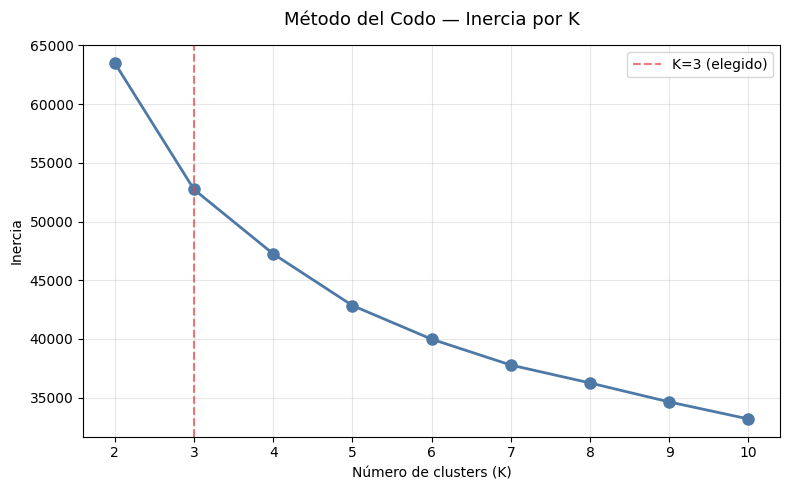

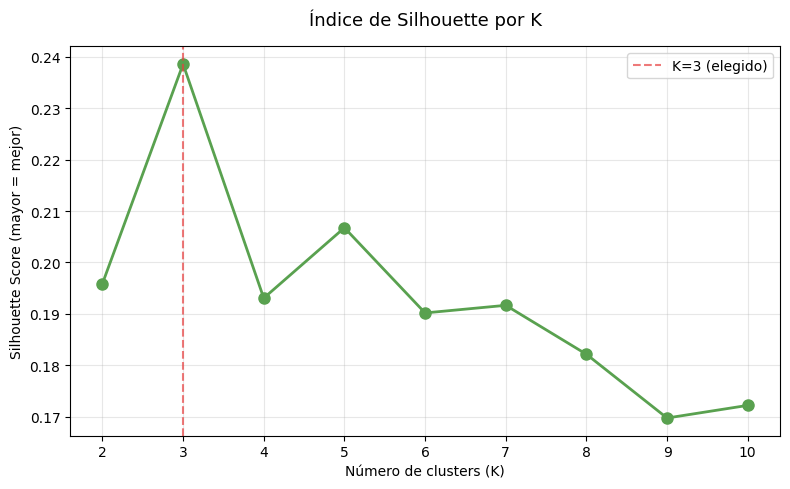

In [23]:
# método del codo

# a K-Means es que hay que decirle cuántos grupos queremos ANTES de entrenarlo
# el Método del Codo me ayuda a averiguarlo
# entrena el modelo con distintos valores de k y mide la inercia de cada uno

# inercia es la suma de las distancias de cada punto a su centroide más cercano
# cuanto menor sea la inercia, más compactos y bien definidos son los clusters

# se podría reducir la inercia a 0 poniendo K=número de filas (cada envío sería
# su propio cluster), pero eso no tiene utilidad
# yo quiero encontrar el punto donde añadir más clusters ya no reduce la inercia
# de forma significativa: ese 'codo' en la curva es el K óptimo.

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# método del Codo
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, marker='o', color='#4e79a7', linewidth=2, markersize=8)
ax.axvline(x=3, color='#e84040', linestyle='--', alpha=0.7, label='K=3 (elegido)')
ax.set_title('Método del Codo — Inercia por K', fontsize=13, pad=15)
ax.set_xlabel('Número de clusters (K)')
ax.set_ylabel('Inercia')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# índice de Silhouette
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, silhouettes, marker='o', color='#59a14f', linewidth=2, markersize=8)
ax.axvline(x=3, color='#e84040', linestyle='--', alpha=0.7, label='K=3 (elegido)')
ax.set_title('Índice de Silhouette por K', fontsize=13, pad=15)
ax.set_xlabel('Número de clusters (K)')
ax.set_ylabel('Silhouette Score (mayor = mejor)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# INTERPRETACIÓN — Método del Codo e Índice de Silhouette

# MÉTODO DEL CODO:
# La curva de inercia cae de forma pronunciada de K=2 a K=3
# (de 63.500 a 52.800), pero a partir de ahí no muestra un punto
# de inflexión dramático y muy marcado como en los ejemplos de libro.
# La pendiente se reduce de forma progresiva sin un codo súper obvio.
# Esto es habitual en datasets de negocio reales donde los grupos
# no están perfectamente separados en el espacio multidimensional.

# ÍNDICE DE SILHOUETTE:
# Es el criterio determinante aquí, precisamente porque el codo
# no es nítido. Su pico máximo y claro se produce en K=3 (0.2386),
# cayendo notablemente en K=4 (0.193) y sin recuperarse en valores
# superiores. Los valores generales son moderados (entre 0.17 y 0.24),
# lo que es esperable en un dataset con variables tan distintas entre sí:
# los clusters no son perfectamente compactos pero sí son los grupos
# más diferenciados posibles con estos datos.

# DECISIÓN: K = 3
# El Silhouette apunta a K=3 de forma inequívoca con su pico máximo.
# El codo lo apoya aunque sin ser concluyente por sí solo.
# Además, 3 grupos tiene una interpretación de negocio clara:
# esperamos encontrar un perfil de alto riesgo, uno de bajo riesgo
# y uno intermedio.
# En la presentación, reconocer que el codo no es perfectamente nítido
# y explicar que por eso apoyamos la decisión en el Silhouette
# demuestra criterio analítico y honestidad metodológica.

print('K elegido: 3')
print(f'Silhouette score con K=3: 0.2386')

K elegido: 3
Silhouette score con K=3: 0.2386


In [ ]:
# los colores que quiero son:
# "#dd62eb", "#6bec5f", "#69b2ed"

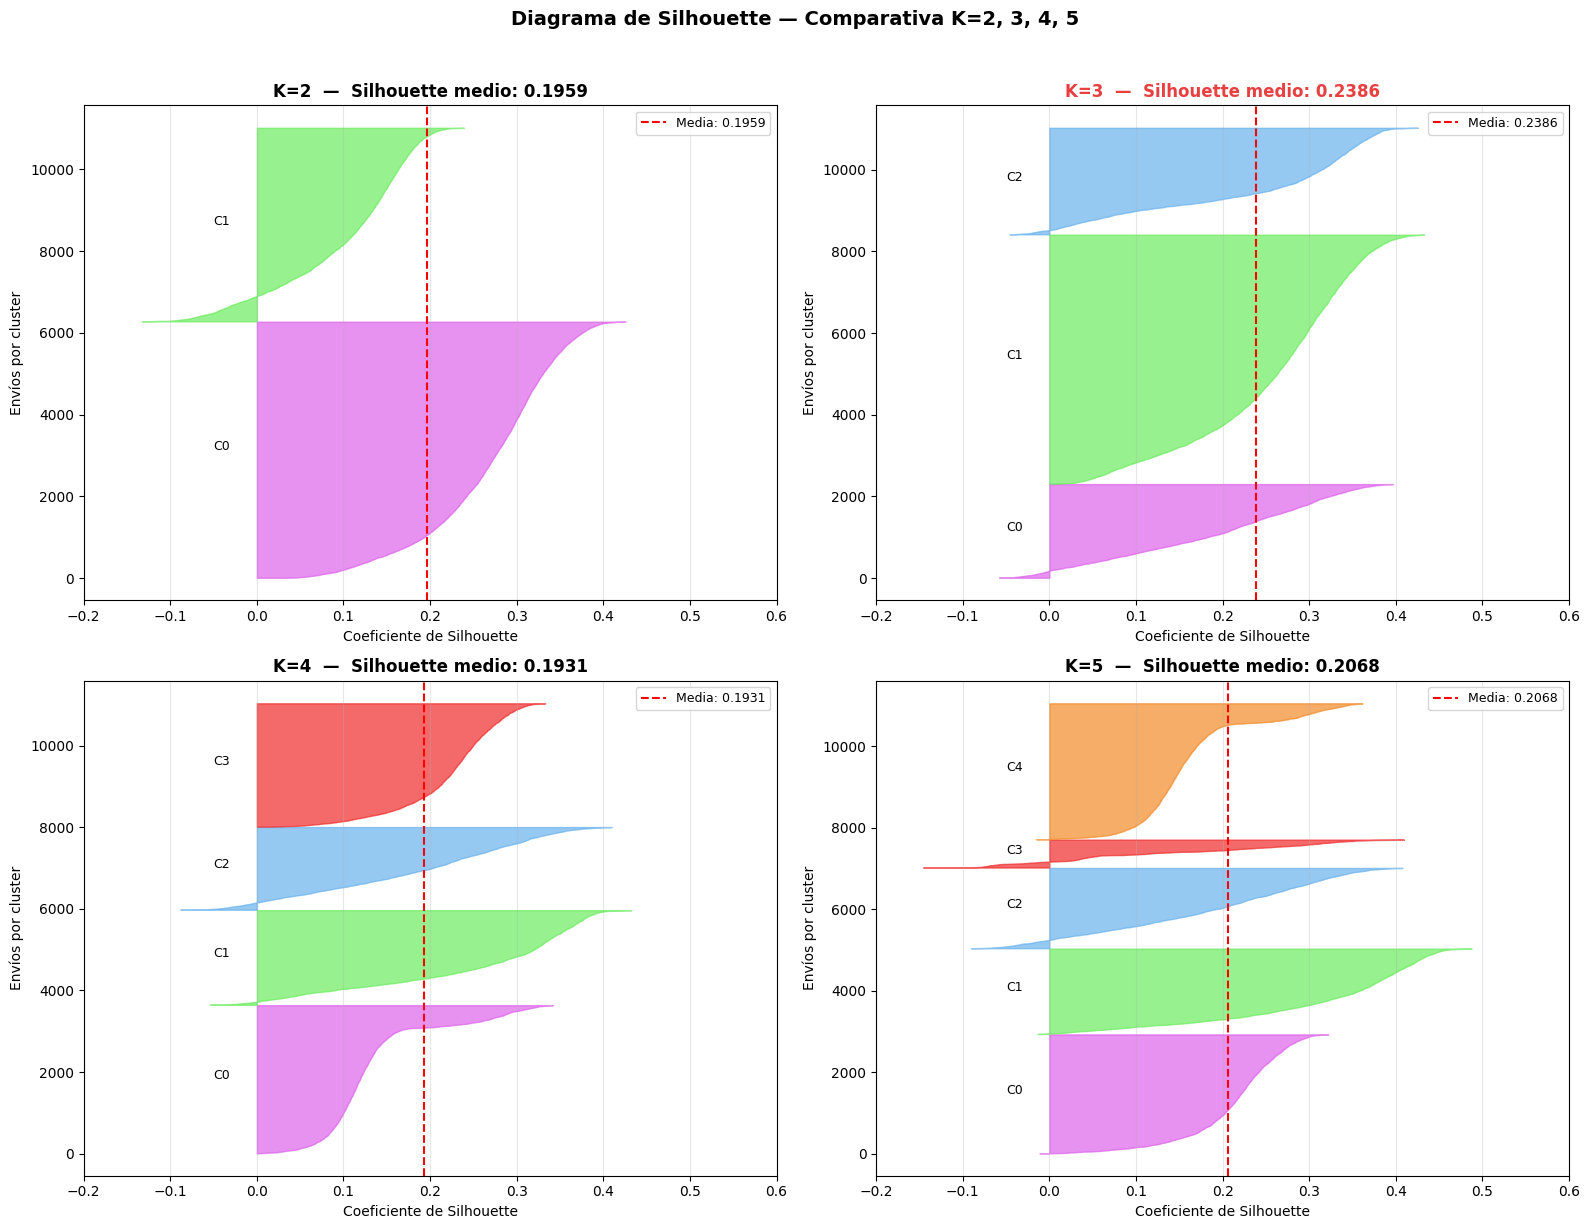

In [ ]:
# diagrama de silhouette

# el índice de silhouette agregado nos da un número resumen,
# pero el diagrama nos muestra la calidad de cada envío individual

# coef cercano a 1: el punto está bien dentro de su cluster
# coef cercano a 0: el punto está en la frontera entre clusters
# coef negativo: el punto probablemente está mal asignado

# cada bloque horizontal es un cluster
# el ancho de cada barra es el coeficiente de silhouette de ese envío
# la línea roja discontinua marca la media global (0.2386)

# comparo los 4 K más prometedores para validar visualmente
# que K=3 es la mejor partición


K_comparar = [2, 3, 4, 5]
colores_base = ["#dd62eb", "#6bec5f", "#69b2ed", "#f02b2b", "#f38a28"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, k in enumerate(K_comparar):
    ax = axes[idx]

    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    silhouette_vals = silhouette_samples(X_scaled, labels_k)
    score_medio = silhouette_score(X_scaled, labels_k)

    y_lower = 10
    for i in range(k):
        cluster_silhouette = np.sort(silhouette_vals[labels_k == i])
        cluster_size = cluster_silhouette.shape[0]
        y_upper = y_lower + cluster_size

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_silhouette,
            alpha=0.7,
            color=colores_base[i % len(colores_base)]
        )
        ax.text(-0.05, y_lower + cluster_size / 2, f'C{i}', fontsize=9)
        y_lower = y_upper + 10

    ax.axvline(x=score_medio, color='red', linestyle='--',
               linewidth=1.5, label=f'Media: {score_medio:.4f}')
    ax.set_title(f'K={k}  —  Silhouette medio: {score_medio:.4f}',
                 fontsize=12, fontweight='bold',
                 color='#e84040' if k == 3 else 'black')
    ax.set_xlabel('Coeficiente de Silhouette')
    ax.set_ylabel('Envíos por cluster')
    ax.set_xlim(-0.2, 0.6)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Diagrama de Silhouette — Comparativa K=2, 3, 4, 5',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# INTERPRETACIÓN — Comparativa de diagramas de Silhouette

# K=2 (score: 0.1959):
# Solo dos bloques muy desequilibrados: C1 es enorme (más de 6.000 envíos)
# y C0 es considerablemente más pequeño. Ambos bloques tienen una cola
# larga hacia la izquierda con coeficientes negativos, lo que indica
# que muchos envíos están en la frontera entre los dos grupos o
# directamente mal asignados. La media es la más baja de los cuatro.
# Dos grupos simplifican demasiado la estructura real de los datos.

# K=3 (score: 0.2386) ← ELEGIDO:
# Es el K con la media global más alta de los cuatro (0.2386).
# Los tres bloques son razonablemente equilibrados en tamaño.
# C2 (azul) es el más grande y tiene la forma más ancha y uniforme:
# es el cluster más cohesionado. C1 (verde) y C0 (morado) también
# muestran una mayoría de puntos por encima de la media global.
# Las colas negativas existen pero son las más cortas de los cuatro K,
# lo que significa que K=3 es el que menos puntos mal asigna.

# K=4 (score: 0.1931):
# La media cae respecto a K=3. C3 (rojo) es enormemente más grande
# que los otros tres, lo que indica que K=4 está fragmentando
# artificialmente grupos que en realidad son homogéneos.
# C1 y C2 tienen colas negativas muy pronunciadas: muchos envíos
# de esos clusters estarían mejor en otro grupo. Añadir un cuarto
# cluster no mejora la calidad, la empeora.

# K=5 (score: 0.2068):
# Ligera recuperación respecto a K=4 pero sin superar a K=3.
# C4 (naranja) es desproporcionadamente grande respecto al resto,
# el mismo problema de desequilibrio que en K=4.
# C3 (rojo) tiene coeficientes casi todos por debajo de la media:
# es un cluster poco cohesionado que no debería existir como grupo
# independiente. Con 5 clusters la interpretación de negocio se
# complica sin ganar cohesión real.

# CONCLUSIÓN VISUAL:
# K=3 es el único K donde los tres bloques son simultáneamente
# equilibrados en tamaño, mayoritariamente por encima de la media
# y con las colas negativas más cortas.
# El gráfico confirma de forma visual e inequívoca la decisión
# tomada con el Método del Codo y el índice de Silhouette agregado.
# K=3 es la partición más natural y robusta de estos datos.

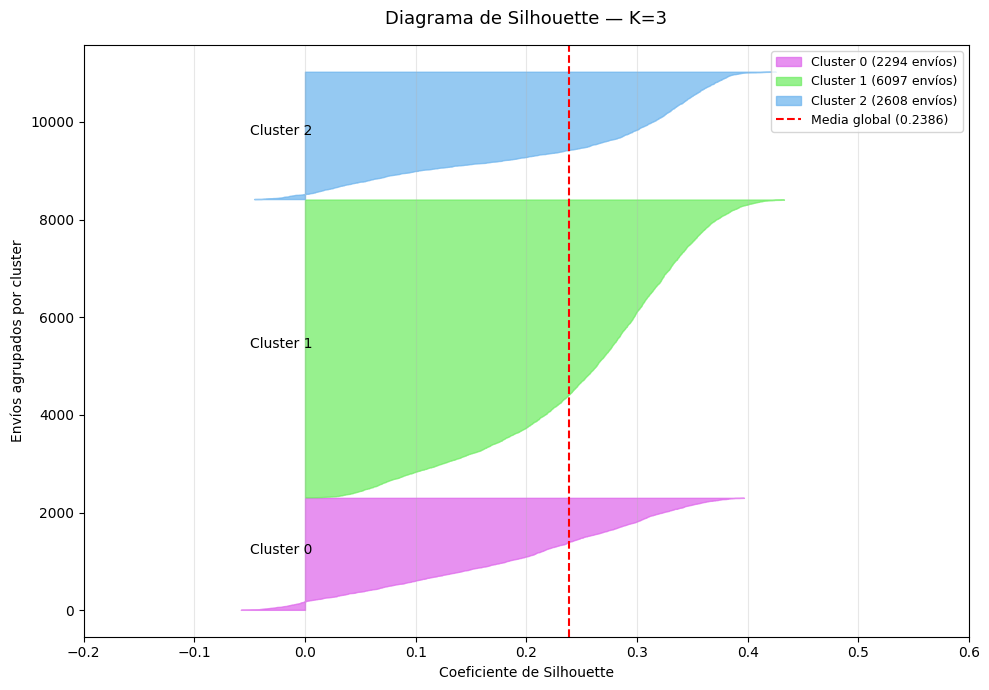

In [53]:
# entreno K=3 para obtener las etiquetas
km_silhouette = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_silhouette = km_silhouette.fit_predict(X_scaled)

# calculo el coeficiente de silhouette de cada punto
silhouette_vals = silhouette_samples(X_scaled, labels_silhouette)

fig, ax = plt.subplots(figsize=(10, 7))

y_lower = 10
colores_silhouette = ["#dd62eb", "#6bec5f", "#69b2ed"]

for i in range(3):
    # coef del cluster i, ordenados
    cluster_silhouette = np.sort(silhouette_vals[labels_silhouette == i])
    cluster_size = cluster_silhouette.shape[0]
    y_upper = y_lower + cluster_size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette,
        alpha=0.7,
        color=colores_silhouette[i],
        label=f'Cluster {i} ({cluster_size} envíos)')

    # etiqueta del cluster en el centro del bloque
    ax.text(-0.05, y_lower + cluster_size / 2, f'Cluster {i}', fontsize=10)
    y_lower = y_upper + 10

# línea de la media global
ax.axvline(x=silhouette_score(X_scaled, labels_silhouette),
           color='red', linestyle='--', linewidth=1.5,
           label=f'Media global ({silhouette_score(X_scaled, labels_silhouette):.4f})')

ax.set_title('Diagrama de Silhouette — K=3', fontsize=13, pad=15)
ax.set_xlabel('Coeficiente de Silhouette')
ax.set_ylabel('Envíos agrupados por cluster')
ax.set_xlim(-0.2, 0.6)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
# conclusión general de que el K elegido es 3


# Hemos aplicado tres herramientas de validación independientes
# y las tres apuntan al mismo resultado:
#
# 1. MÉTODO DEL CODO: la curva de inercia reduce su pendiente
#    de forma más notable a partir de K=3. Aunque el codo no es
#    dramático (algo habitual en datos de negocio reales), es el
#    punto donde añadir más clusters empieza a aportar menos valor.
#
# 2. ÍNDICE DE SILHOUETTE AGREGADO: pico máximo en K=3 (0.2386),
#    con una caída notable en K=4 (0.1931) que ya no se recupera
#    en valores superiores.
#
# 3. DIAGRAMA DE SILHOUETTE COMPARATIVO: K=3 es el único K donde
#    los tres bloques son simultáneamente equilibrados en tamaño,
#    mayoritariamente por encima de la media global y con las colas
#    negativas más cortas, es decir, el que menos puntos mal asigna.
#
# Las tres evidencias convergen en K=3.
# No es una decisión arbitraria ni basada en un único criterio:
# es el resultado de un proceso de validación riguroso con
# herramientas complementarias que se refuerzan mutuamente.
#
# Adicionalmente, K=3 tiene una interpretación de negocio natural:
# tres perfiles de envío (alto riesgo, riesgo medio, bajo riesgo)
# que la empresa puede usar de forma accionable.
# Un K mayor fragmentaría esos perfiles en grupos demasiado pequeños
# para tomar decisiones operativas concretas.

print('K = 3 validado por tres métodos independientes. Procedemos al entrenamiento.')

K = 3 validado por tres métodos independientes. Procedemos al entrenamiento.


Ahora entreo el modelo

In [29]:
# vamos a entrenar

kmeans = KMeans(
    n_clusters=3, # k
    random_state=42,
    n_init=10) # 10 inicializaciones distintas, nos quedamos con la mejor (así evita quedarse atrapado en un mínimo local por mala inicialización)

# .fit_predict() entrena el modelo y asigna cada envío a un cluster (0, 1 o 2)
labels = kmeans.fit_predict(X_scaled)

# añadimos el cluster y el target al dataframe para analizar
df_analisis = X_cluster.copy()
df_analisis['Cluster'] = labels
df_analisis['Retraso'] = target.values


print('Distribución de envíos por cluster:')
print(df_analisis['Cluster'].value_counts().sort_index())

Distribución de envíos por cluster:
Cluster
0    2294
1    6097
2    2608
Name: count, dtype: int64


In [ ]:
# distribución de envíos por cluster

# el K-Means ha dividido los 10.999 envíos en tres grupos
# de tamaños distintos pero razonablemente equilibrados:

# Cluster 0 → 2.294 envíos (20.9% del total)
#   el grupo más pequeño. como veremos a continuación,
#   es el grupo más homogéneo y con la señal más clara.

# Cluster 1 → 6.097 envíos (55.4% del total)
#   el grupo mayoritario. representa el perfil de envío
#   más común en el dataset.

# Cluster 2 → 2.608 envíos (23.7% del total)
#   tamaño similar al Cluster 0 pero con un perfil
#   de cliente distinto, como veremos en el análisis.

# ningún cluster es despreciablemente pequeño ni dominante al 90%,
# lo que confirma que K=3 produce una partición equilibrada y útil

Ahora analizo los cluster:

TASA DE RETRASO POR CLUSTER:
         Tamaño  Tasa_retraso_%
Cluster                        
0          2294            99.5
1          6097            47.9
2          2608            52.3



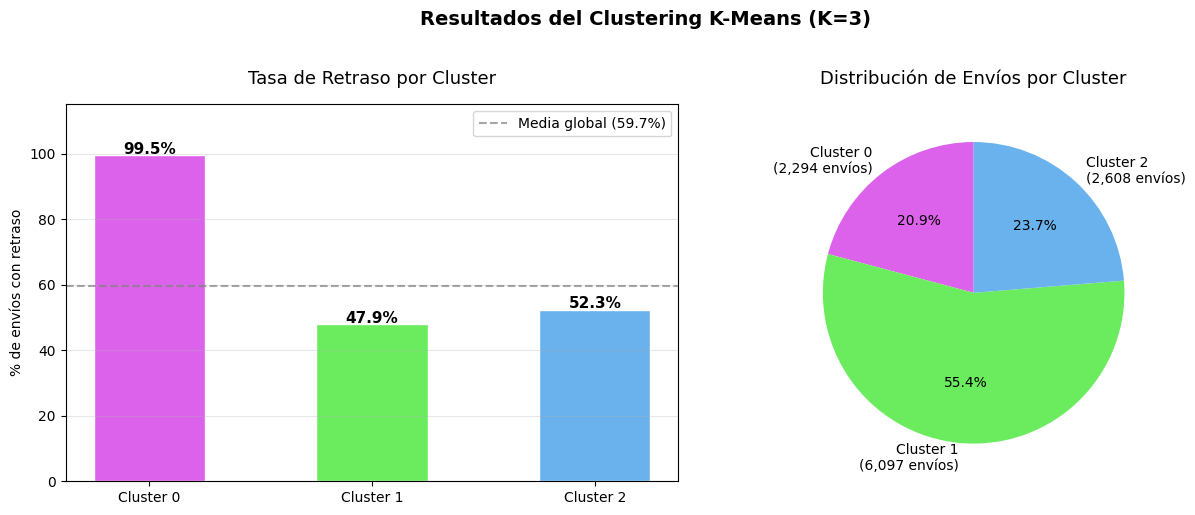

In [43]:
# tasa de retraso por cluster

# revelo el target que el modelo no conocía y veo si los grupos que
# encontró tienen tasas de retraso distintas
# si los clusters son útiles, deberían separar envíos con distinto nivel de riesgo

tasa_retraso = df_analisis.groupby('Cluster')['Retraso'].mean() * 100
tamanio = df_analisis['Cluster'].value_counts().sort_index()

resumen = pd.DataFrame({
    'Tamaño': tamanio,
    'Tasa_retraso_%': tasa_retraso.round(1)})

print('TASA DE RETRASO POR CLUSTER:')
print(resumen.to_string())
print()

# visualización
colores_clusters = ["#dd62eb", "#6bec5f", "#69b2ed"]
etiquetas = ['Cluster 0', 'Cluster 1', 'Cluster 2']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# tasa de retraso
bars = axes[0].bar(etiquetas, tasa_retraso.values, color=colores_clusters, edgecolor='white', width=0.5)
axes[0].axhline(y=59.7, color='gray', linestyle='--', alpha=0.7, label='Media global (59.7%)')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Tasa de Retraso por Cluster', fontsize=13, pad=15)
axes[0].set_ylabel('% de envíos con retraso')
axes[0].set_ylim(0, 115)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Tamaño de clusters
axes[1].pie(
    tamanio.values,
    labels=[f'Cluster {i}\n({v:,} envíos)' for i, v in enumerate(tamanio.values)],
    colors=colores_clusters,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10})
axes[1].set_title('Distribución de Envíos por Cluster', fontsize=13, pad=15)

plt.suptitle('Resultados del Clustering K-Means (K=3)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# INTERPRETACIÓN — Tasa de retraso por cluster

# este es el momento más importante del notebook:
# el K-Means, sin haber visto ni una sola etiqueta de retraso,
# ha conseguido separar los envíos en tres grupos con tasas
# de retraso radicalmente distintas entre sí.

# 🟣​ CLUSTER 0 — 2.294 envíos (20.9%) — Tasa de retraso: 99.5%
#    el hallazgo más impactante del análisis.
#    prácticamente el 100% de estos envíos llegan tarde.
#    el modelo los ha agrupado porque comparten unas características
#    tan específicas y tan determinantes que hacen el retraso
#    casi inevitable. veremos cuáles en el perfil de variables.
#    es el grupo más pequeño pero el más crítico para el negocio.

# 🟢 CLUSTER 1 — 6.097 envíos (55.4%) — Tasa de retraso: 47.9%
#    el grupo mayoritario y el de menor riesgo relativo.
#    con una tasa del 47.9% está 12 puntos por debajo de la media
#    global (59.7%), lo que lo convierte en el perfil de envío
#    más manejable de los tres.
#    representa más de la mitad del total de envíos.

# 🔵​ CLUSTER 2 — 2.608 envíos (23.7%) — Tasa de retraso: 52.3%
#    el grupo intermedio. ligeramente por debajo de la media global
#    pero con un perfil de cliente distinto al Cluster 1,
#    como veremos a continuación en el análisis de variables.

# LO MÁS RELEVANTE DE ESTE GRÁFICO:
# los tres grupos tienen tasas de retraso claramente diferentes
# entre sí: 99.5%, 47.9% y 52.3%.
# esa diferencia no la hemos puesto nosotros: la ha encontrado
# el modelo por sí solo a partir de las características del envío.
# es la prueba de que los clusters son reales e informativos,
# no una partición arbitraria de los datos.

# El Cluster 0 es el hallazgo más importante de este análisis.
# 2.294 envíos identificables de antemano con retraso casi garantizado
# Representa el 20.9% de los envíos pero concentra prácticamente
# todos sus retrasos. Si la empresa pudiera identificar estos envíos
# antes de salir del almacén, podría actuar de forma preventiva
# en el 100% de los casos. 

¿Qué caracteriza a los clusters?

PERFIL MEDIO DE CADA CLUSTER:

         Weight_in_gms  Discount_offered  Cost_of_the_Product  Customer_care_calls  Customer_rating  Prior_purchases  Product_importance
Cluster                                                                                                                                 
0               2214.0              40.1                188.7                  3.7              3.0              3.1                 1.6
1               4801.5               5.9                201.4                  3.7              3.0              3.1                 1.6
2               2153.7               7.4                249.6                  5.2              3.0              5.1                 1.5



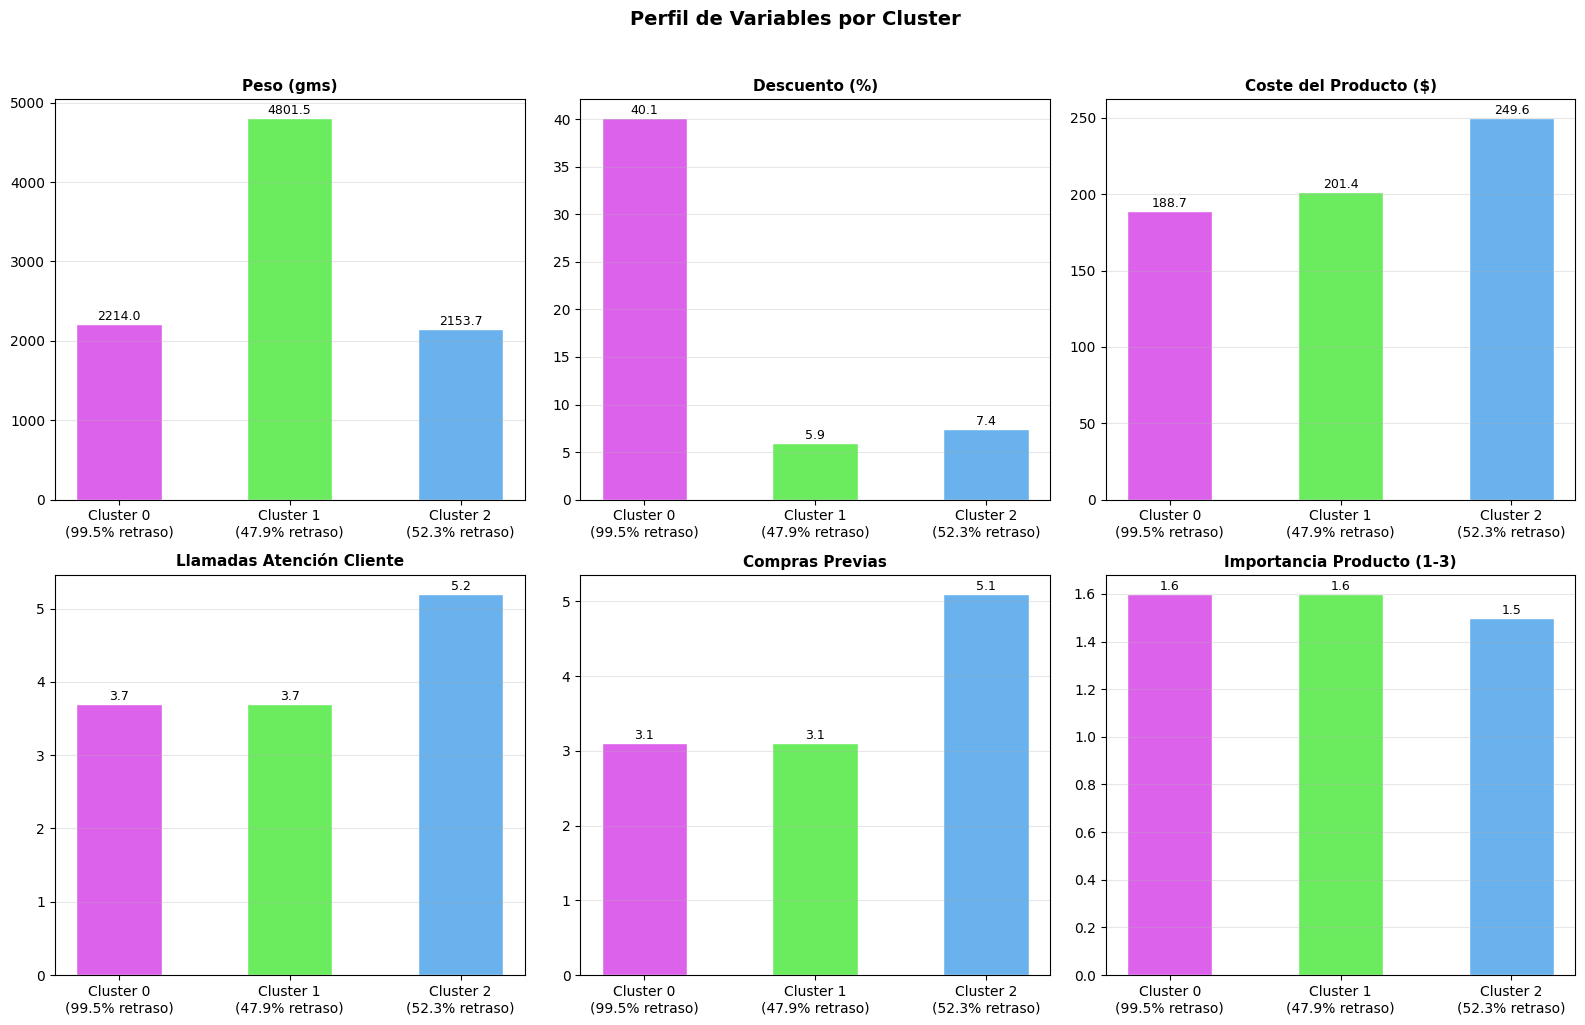

In [44]:
# perfil de cada cluster
# analizo las medias de cada variable por cluster para entender
# qué características definen a cada grupo

perfil = df_analisis.groupby('Cluster')[cols_cluster].mean().round(1)

print('PERFIL MEDIO DE CADA CLUSTER:')
print()
print(perfil.to_string())
print()


# visualización del perfil con gráfico de barras agrupadas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

variables_plot = ['Weight_in_gms', 'Discount_offered', 'Cost_of_the_Product',
                  'Customer_care_calls', 'Prior_purchases', 'Product_importance']

titulos = ['Peso (gms)', 'Descuento (%)', 'Coste del Producto ($)',
           'Llamadas Atención Cliente', 'Compras Previas', 'Importancia Producto (1-3)']

for ax, var, titulo in zip(axes, variables_plot, titulos):
    valores = perfil[var]
    bars = ax.bar(['Cluster 0\n(99.5% retraso)',
                   'Cluster 1\n(47.9% retraso)',
                   'Cluster 2\n(52.3% retraso)'],
                  valores,
                  color=colores_clusters,
                  edgecolor='white',
                  width=0.5)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + ax.get_ylim()[1]*0.01,
                f'{bar.get_height():.1f}',
                ha='center', fontsize=9)

plt.suptitle('Perfil de Variables por Cluster', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Perfil de variables por cluster

# el gráfico revela la identidad de cada grupo.
# cada cluster tiene UNA variable que lo define y lo diferencia
# del resto. esa es la clave para entender qué tipo de envío es cada uno.

# 🟣​​ CLUSTER 0 — "EL GRUPO DEL DESCUENTO ALTO" (99.5% retraso)
#    la variable que define este cluster es Discount_offered: media de 40.1%
#    frente al 5.9% del Cluster 1 y el 7.4% del Cluster 2.
#    el descuento es entre 5 y 7 veces mayor que en los otros grupos.
#    el peso (2.214g) y el coste (188.7$) son los más bajos de los tres,
#    lo que confirma que NO es el tamaño ni el valor del paquete lo que
#    genera el retraso: es exclusivamente el descuento alto.
#    las campañas promocionales agresivas saturan la capacidad logística
#    y hacen el retraso prácticamente inevitable.
#    → ACCIÓN: cualquier envío con descuento > 25% debe activar
#      automáticamente una alerta proactiva al cliente.

# 🟢​ CLUSTER 1 — "EL GRUPO DEL PAQUETE PESADO" (47.9% retraso)
#    define a los paquetes más pesados con diferencia (media 4.801g,
#    más del doble que los otros dos grupos).
#    a pesar de tener el mayor peso, tiene la tasa de retraso más baja.
#    este es el hallazgo contraintuitivo más importante del clustering:
#    el peso por sí solo NO determina el retraso.
#    es la combinación de peso alto CON descuento alto la que dispara
#    los problemas. este grupo tiene descuento bajo (5.9%), lo que
#    lo mantiene bajo control a pesar de su peso elevado.
#    → ACCIÓN: paquetes pesados con descuento bajo son manejables.
#      no requieren atención prioritaria especial.

# 🔵​ CLUSTER 2 — "EL GRUPO DEL CLIENTE FIDELIZADO" (52.3% retraso)
#    lo que distingue a este cluster no es el peso (2.153g, similar
#    al Cluster 0) ni el descuento (7.4%, similar al Cluster 1),
#    sino el perfil del cliente:
#    Prior_purchases media de 5.1 frente a 3.1 en los otros dos grupos.
#    Customer_care_calls de 5.2 frente a 3.7 en los otros.
#    son clientes con más historial de compras y que contactan más
#    con atención al cliente. esas llamadas frecuentes pueden ser
#    una señal temprana de que algo no funciona bien en el proceso
#    de entrega para estos perfiles de cliente más exigentes.
#    el coste del producto también es el más alto (249.6$),
#    lo que sugiere que son clientes que compran productos de mayor valor.
#    → ACCIÓN: clientes con más de 4 compras previas y más de 4 llamadas
#      al servicio merecen seguimiento especial de su envío.

# EL ARGUMENTO MÁS PODEROSO DE ESTE ANÁLISIS:
# el Cluster 0 no es solo un hallazgo del clustering.
# es la tercera vez que el mismo patrón aparece en el proyecto,
# desde tres metodologías completamente independientes:
#
#   1. EDA (Notebook 01): el histograma de descuentos mostró que
#      con descuento > 10.5 USD, el 100% de los envíos llegaban tarde.
#      era una observación visual y estadística.
#
#   2. Árbol de Decisión (Notebook 02): el modelo situó el descuento
#      como primera pregunta de decisión (nodo raíz), con una rama
#      de pureza absoluta (gini=0) para descuentos altos.
#      era una regla aprendida de forma supervisada.
#
#   3. K-Means (este notebook): el modelo, SIN ver ninguna etiqueta
#      de retraso, agrupó espontáneamente los envíos con descuento
#      alto en un único cluster con tasa de retraso del 99.5%.
#      es una confirmación desde el aprendizaje no supervisado.
#
# tres análisis distintos, tres metodologías distintas, la misma conclusión.
# eso no es una coincidencia: es una señal robusta y fiable de que
# el descuento alto es EL factor crítico de la logística de esta empresa.
# cualquier decisión de negocio que ignore este patrón está ignorando
# la evidencia más sólida de todo el proyecto.

Varianza explicada por los 2 componentes principales: 42.7%
  PC1: 23.3%
  PC2: 19.3%

Nota: un 42.7% de varianza explicada es bajo, lo que confirma
que los datos son multidimensionales y complejos.
El gráfico es una aproximación visual, no una representación exacta.


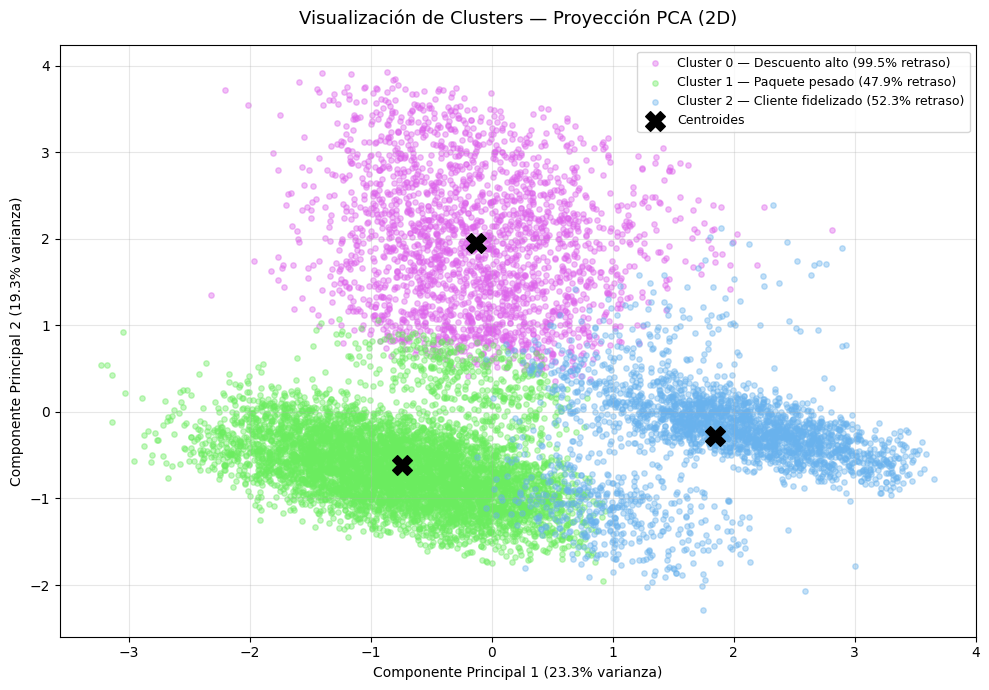

In [ ]:
# visualización con PCA (los clusters en 2 dimensiones)

# tengo 7 variables, lo que hace imposible visualizar los clusters directamente
# PCA (Análisis de Componentes Principales) reduce esas 7 dimensiones a 2 manteniendo
# la máxima varianza posible, permitiéndo dibujar los clusters en un gráfico 2D

# PCA no cambia los clusters, solo los proyecta en 2D para que podamos verlos
# es una herramienta de visualización, no de modelado

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza_total = sum(pca.explained_variance_ratio_)
print(f'Varianza explicada por los 2 componentes principales: {varianza_total:.1%}')
print(f'  PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'  PC2: {pca.explained_variance_ratio_[1]:.1%}')
print()
print('Nota: un 42.7% de varianza explicada es bajo, lo que confirma')
print('que los datos son multidimensionales y complejos.')
print('El gráfico es una aproximación visual, no una representación exacta.')

# gráfico de los clusters en 2D
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels

fig, ax = plt.subplots(figsize=(10, 7))

nombres_clusters = {
    0: 'Cluster 0 — Descuento alto (99.5% retraso)',
    1: 'Cluster 1 — Paquete pesado (47.9% retraso)',
    2: 'Cluster 2 — Cliente fidelizado (52.3% retraso)'}

for cluster_id, color in zip([0, 1, 2], colores_clusters):
    mask = df_pca['Cluster'] == cluster_id
    ax.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        c=color,
        label=nombres_clusters[cluster_id],
        alpha=0.4,
        s=15)

# marco los centroides proyectados en PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c='black',
    marker='X',
    s=200,
    zorder=5,
    label='Centroides')

ax.set_title('Visualización de Clusters — Proyección PCA (2D)', fontsize=13, pad=15)
ax.set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# INTERPRETACIÓN — Visualización PCA (2D)

# la varianza explicada es del 42.7% (PC1: 23.3% + PC2: 19.3%).
# es un valor moderado: estamos viendo menos de la mitad de la
# información real de los 7 datos originales proyectada en 2 dimensiones.
# el gráfico es una aproximación visual útil, no una representación exacta.

# aun así, el gráfico muestra una separación visual bastante clara
# entre los tres clusters, especialmente entre el Cluster 0 y los otros dos:

# 🟣​ CLUSTER 0 (morado, descuento alto):
#    se concentra en la parte superior del gráfico (PC2 alto).
#    está claramente separado verticalmente de los otros dos clusters.
#    esto refleja que el descuento alto, la variable que define este grupo,
#    tiene un peso importante en el segundo componente principal (PC2).
#    su centroide (X negro) está bien centrado dentro del grupo,
#    lo que confirma su cohesión interna.

# 🟢​ CLUSTER 1 (verde, paquete pesado):
#    ocupa la parte izquierda y central del gráfico (PC1 negativo).
#    es el cluster más extendido horizontalmente, lo que refleja
#    que el peso (variable dominante en PC1) tiene mucha dispersión.
#    su centroide está bien posicionado en el centro del grupo.

# 🔵​ CLUSTER 2 (azul, cliente fidelizado):
#    se extiende hacia la derecha del gráfico (PC1 positivo alto).
#    está separado del Cluster 1 en el eje horizontal, lo que sugiere
#    que las variables que lo definen (compras previas y llamadas al
#    servicio) contribuyen principalmente al primer componente principal.
#    hay cierta superposición con el Cluster 1 en la zona central,
#    lo que es esperable: en 7 dimensiones están más separados
#    de lo que el gráfico 2D puede mostrar.

# CONCLUSIÓN VISUAL:
# los tres clusters tienen zonas propias bien diferenciadas en el gráfico,
# con los centroides claramente separados entre sí.
# la superposición en las fronteras entre clusters es normal:
# representa los envíos con características intermedias que podrían
# pertenecer a más de un grupo. no invalida el análisis.
# la prueba de que los clusters son reales y útiles no está en la
# separación visual sino en las tasas de retraso: 99.5%, 47.9% y 52.3%.
# esa diferencia sí que es inequívoca.

CONCLUSIONES

In [46]:
# ¿cómo complementa el clustering al modelo supervisado?

# el modelo supervisado del notebook 02 (Random Forest) responde a:
#   → "¿Eeste envío concreto llegará tarde?"
#   predice sí o no para cada envío individual

# el K-Means de este notebook responde a:
#   → "¿qué tipos de envíos existen y cuál es su nivel de riesgo estructural?"
#   no predice un caso concreto, sino que identifica patrones globales

# usados juntos forman un sistema más completo:
#   el clustering identifica los segmentos de riesgo antes de que salgan del almacén
#   el modelo supervisado da la predicción individual para cada envío

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║               CONCLUSIÓN — CLUSTERING K-Means (K=3)                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  El K-Means ha identificado 3 perfiles naturales de envío                    ║
║  sin haber visto ninguna etiqueta de retraso:                                ║
║                                                                              ║
║  🟣​ CLUSTER 0 — "Descuento alto"    2.294 envíos — 99.5% de retraso          ║
║     Descuento medio: 40.1%  |  Peso medio: 2.214g                            ║
║     El descuento extremo satura la logística. Retraso casi garantizado.      ║
║     → Activar alerta proactiva para cualquier envío con descuento > 25%      ║
║                                                                              ║
║  🟢 CLUSTER 1 — "Paquete pesado"    6.097 envíos — 47.9% de retraso          ║
║     Descuento medio: 5.9%   |  Peso medio: 4.802g                            ║
║     Paquetes pesados pero con descuento bajo. El peso solo no es el          ║
║     problema: sin descuento alto, la tasa baja al 47.9%.                     ║
║     → Grupo mayoritario y más manejable. Prioridad logística estándar.       ║
║                                                                              ║
║  🔵​ CLUSTER 2 — "Cliente fidelizado"  2.608 envíos — 52.3% de retraso        ║
║     Compras previas: 5.1   |  Llamadas al servicio: 5.2                      ║
║     Clientes con más historial y más contacto con atención al cliente.       ║
║     Las llamadas pueden ser señal temprana de problema en la entrega.        ║
║     → Seguimiento especial para clientes con > 4 compras y > 4 llamadas      ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  💼 IMPACTO DE NEGOCIO:                                                      ║
║     El Cluster 0 representa el 20.9% de los envíos pero con un 99.5%         ║
║     de retraso es el segmento donde cualquier mejora logística tiene         ║
║     el mayor impacto. Identificar estos envíos en el almacén antes de        ║
║     que salgan permite tomar medidas preventivas sistemáticas.               ║
║                                                                              ║
║  🔗 COMPLEMENTO AL MODELO SUPERVISADO:                                       ║
║     Random Forest → predice si un envío concreto llegará tarde               ║
║     K-Means       → identifica qué perfil de envío tiene más riesgo          ║
║     Juntos forman un sistema de alerta temprana más completo:                ║
║     el clustering actúa a nivel estratégico (segmentos de riesgo)            ║
║     y el modelo supervisado actúa a nivel operativo (envío individual)       ║
║                                                                              ║
║  🔭 PRÓXIMOS PASOS:                                                          ║
║     — Añadir la variable Cluster como feature al modelo supervisado          ║
║       para ver si mejora el Recall del Random Forest                         ║
║     — Explorar otros algoritmos de clustering (DBSCAN) que no requieren      ║
║       definir K de antemano y detectan outliers como cluster propio          ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║               CONCLUSIÓN — CLUSTERING K-Means (K=3)                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  El K-Means ha identificado 3 perfiles naturales de envío                    ║
║  sin haber visto ninguna etiqueta de retraso:                                ║
║                                                                              ║
║  🟣​ CLUSTER 0 — "Descuento alto"    2.294 envíos — 99.5% de retraso          ║
║     Descuento medio: 40.1%  |  Peso medio: 2.214g                            ║
║     El descuento extremo satura la logística. Retraso casi garantizado.      ║
║     → Activar alerta proactiva para cualquier envío con descuento > 25%      ║
║                                                                              ║
║  🟢 CLUSTER 1 — "Paquete p